C:\Users\danie\AppData\Local\Temp\ipykernel_36096\811183220.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


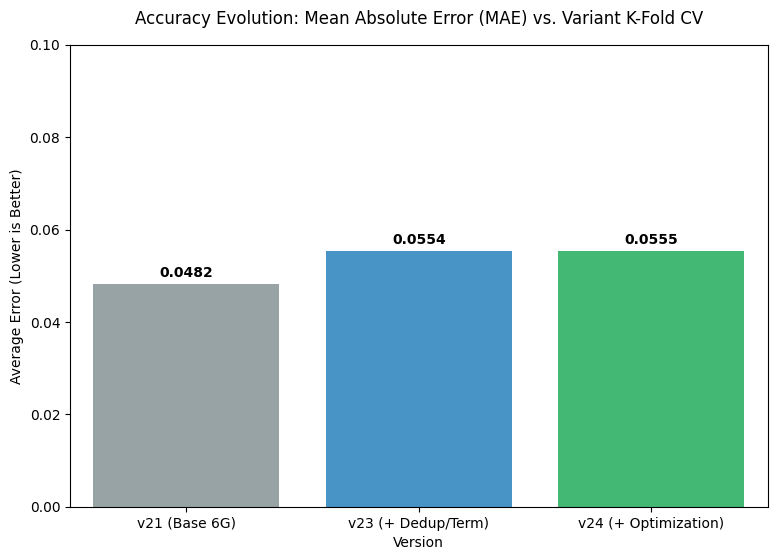

In [1]:
# ==========================================
# CELL: MAE Tracking the Evolution of Gen_Shadow
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('master_benchmark_ultimate.csv')

df_mae_evo = df.copy()

# Calculate absolute distance from the Variant K-Fold empirical ground truth
df_mae_evo['Error_v21'] = abs(df_mae_evo['6G_v21'] - df_mae_evo['Fit_3Fold_Var'])
df_mae_evo['Error_v23'] = abs(df_mae_evo['6G_v23'] - df_mae_evo['Fit_3Fold_Var'])
df_mae_evo['Error_v24'] = abs(df_mae_evo['6G_v24'] - df_mae_evo['Fit_3Fold_Var'])

df_melted_mae_evo = df_mae_evo.melt(
    id_vars=['Miner', 'Dataset'], 
    value_vars=['Error_v21', 'Error_v23', 'Error_v24'], 
    var_name='Version', 
    value_name='Absolute_Error'
)

name_map_mae_evo = {
    'Error_v21': 'v21 (Base 6G)', 
    'Error_v23': 'v23 (+ Dedup/Term)', 
    'Error_v24': 'v24 (+ Optimization)'
}
df_melted_mae_evo['Version'] = df_melted_mae_evo['Version'].map(name_map_mae_evo)

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=df_melted_mae_evo, 
    x='Version', 
    y='Absolute_Error', 
    estimator=np.mean, 
    errorbar=None, 
    palette=['#95A5A6', '#3498DB', '#2ECC71']
)

plt.title('Accuracy Evolution: Mean Absolute Error (MAE) vs. Variant K-Fold CV', pad=15)
plt.ylabel('Average Error (Lower is Better)')
plt.ylim(0, 0.1) # Adjusted for the scale of these errors

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

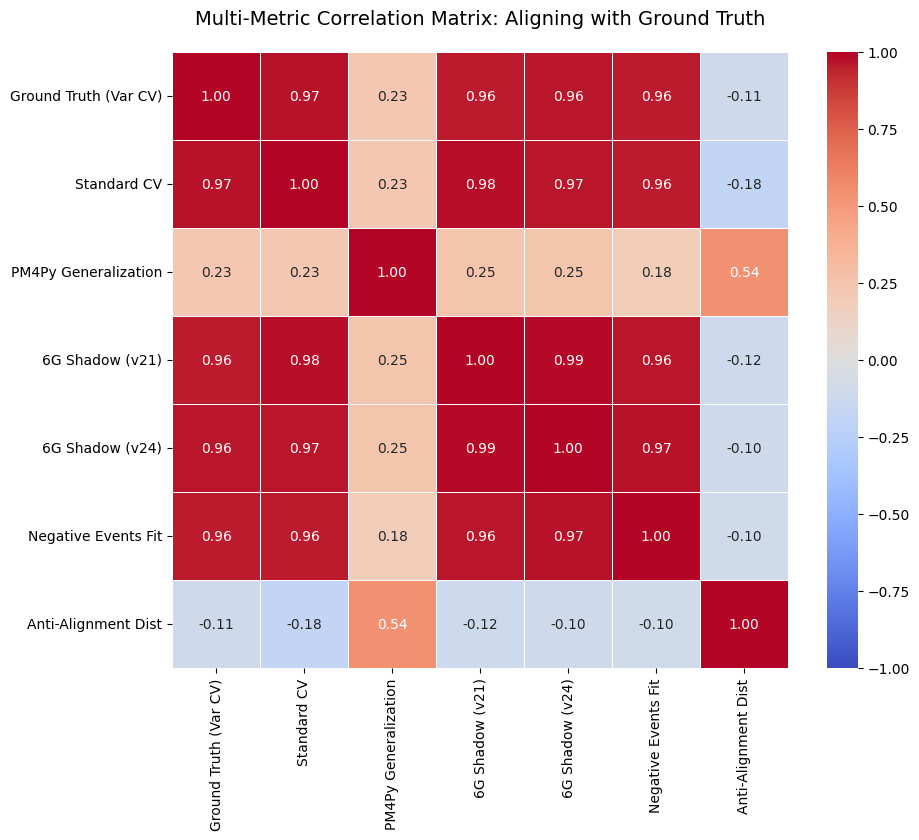

In [2]:
# =====================================================================
# CELL 9: MULTI-METRIC CORRELATION HEATMAP
# =====================================================================
# Select all numerical metric columns (excluding state space size due to -1 crash values)
metric_cols = [
    'Fit_3Fold_Var', 'Fit_3Fold_Std', 'PM4Py_Gen', 
    '6G_v21', '6G_v24', 'Negative_Events', 'Anti_Align_Dist'
]

# Calculate Spearman rank-based correlation matrix
corr_matrix = df[metric_cols].corr(method='spearman')

# Rename columns for cleaner presentation labels
clean_labels = {
    'Fit_3Fold_Var': 'Ground Truth (Var CV)',
    'Fit_3Fold_Std': 'Standard CV',
    'PM4Py_Gen': 'PM4Py Generalization',
    '6G_v21': '6G Shadow (v21)',
    '6G_v24': '6G Shadow (v24)',
    'Negative_Events': 'Negative Events Fit',
    'Anti_Align_Dist': 'Anti-Alignment Dist'
}
corr_matrix = corr_matrix.rename(index=clean_labels, columns=clean_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Multi-Metric Correlation Matrix: Aligning with Ground Truth', pad=20, fontsize=14)
plt.show()